# Multiple Linear Regression (MLR)

In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Load the data set
data = pd.read_csv("YachtHydrodynamics.csv")
print(data)

     Longitudinal position of the center of buoyancy, adimensional  \
0                                                 -2.3               
1                                                 -2.3               
2                                                 -2.3               
3                                                 -2.3               
4                                                 -2.3               
..                                                 ...               
303                                               -2.3               
304                                               -2.3               
305                                               -2.3               
306                                               -2.3               
307                                               -2.3               

     Prismatic coefficient  Length-displacement ratio  Beam-draught ratio  \
0                    0.568                       4.78                3.99   
1    

In [ ]:
# Split data into features and target
y = data.iloc[:,0].values
X = data.iloc[:,1:].values
X = np.c_[np.ones(X.shape[0]),X]
print("X_shape:",X.shape)
print("Y_shape: ",y.shape)

X_shape: (308, 7)
Y_shape:  (308,)


In [9]:
# Train-Test Splitting

np.random.seed(42)                                 # for reproducibility
rows = X.shape[0]                                  # number of rows
rp = np.random.permutation(rows)

train_size = int(np.round(rows * 0.8))
train_idx, test_idx = rp[:train_size], rp[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Features training dataset: ", X_train)
print("Target training dataset: ", y_train)

print("Features testing dataset: ", X_test)
print("Target testing dataset: ", y_test)

print("Training sample:",X_train.shape[0])
print("Testing sample:",y_test.shape[0])

Features training dataset:  [[ 1.     0.6    5.1   ...  3.51   0.325  6.31 ]
 [ 1.     0.568  4.78  ...  3.17   0.35   7.16 ]
 [ 1.     0.574  4.36  ...  2.76   0.15   0.35 ]
 ...
 [ 1.     0.565  4.78  ...  2.76   0.4   21.4  ]
 [ 1.     0.53   4.78  ...  3.15   0.15   0.32 ]
 [ 1.     0.6    4.34  ...  2.73   0.25   1.62 ]]
Target training dataset:  [-2.3 -2.3 -2.4 -2.4 -2.3 -2.4 -2.3 -2.3 -5.  -2.3 -2.4  0.  -2.3 -2.3
 -2.3 -2.3 -2.3  0.   0.  -5.  -2.4 -2.4  0.  -2.3 -2.4 -5.  -2.2 -2.3
 -5.  -5.  -2.4 -2.3 -2.4  0.  -2.3 -2.4 -2.3 -2.3 -2.3 -2.2 -2.3 -2.3
 -5.  -5.  -2.3 -2.3  0.  -2.3 -2.3 -2.4 -2.2 -5.  -5.  -2.3 -5.   0.
 -2.3 -2.3 -2.3 -2.3  0.   0.   0.  -2.4 -5.   0.  -2.3 -2.4 -5.  -2.4
 -2.2 -2.3 -2.3 -2.3 -2.3  0.  -2.4 -5.  -5.  -2.3 -5.  -2.3 -5.   0.
 -2.3 -2.3 -2.4 -2.2 -5.  -5.  -2.3 -5.  -2.4 -2.3 -2.3 -2.4 -2.3 -2.3
 -5.  -5.  -2.3 -2.4 -5.  -2.3 -2.3 -2.3  0.  -5.  -2.4 -2.4 -2.4 -2.3
 -2.3  0.   0.  -2.2 -2.3  0.  -2.3  0.   0.  -2.3  0.  -5.  -2.2  0.
 -2.3 -2.3

In [ ]:
# Compute Regression Coefficients
# β = (XᵀX)⁻¹Xᵀy
XtX = np.dot(X_train.T, X_train)
XtX_inv = np.linalg.inv(XtX)
XtX_inv_Xt = np.dot(XtX_inv, X_train.T)
beta = np.dot(XtX_inv_Xt, y_train)

print("Regression Coefficients (β):\n", beta)


Regression Coefficients (β):
 [ 2.77258477e-01 -3.68114951e+00 -1.20140370e+00  4.57901626e-01
  1.10171224e+00 -7.20828137e-01  2.76487696e-03]


In [ ]:
# Predict on Test Data
y_pred = np.dot(X_test, beta)

# Display few predictions
print(y_pred)

[-2.37094483 -2.36800805 -2.24776472 -2.40307333 -2.44264186 -2.40402782
 -2.40439175 -2.38981221 -2.40158871 -2.46446002 -2.33546961 -2.33944603
 -2.47830511 -2.40711803 -2.45717185 -2.34426656 -2.43352968 -2.43113469
 -2.45746935 -2.24490022 -2.44167533 -2.41266183 -2.46306733 -2.41979886
 -2.40466823 -2.42442776 -2.36556721 -2.46691693 -2.41860489 -2.45365609
 -2.3085792  -2.43733649 -2.44074219 -2.44823253 -2.44967422 -2.46426583
 -2.42300352 -2.4321229  -2.36606816 -2.34417302 -2.41871624 -2.48656883
 -2.31859695 -2.36492379 -2.44942538 -2.4612846  -2.48686993 -2.40377898
 -2.46639588 -2.3945129  -2.46607916 -2.30997037 -2.34892894 -2.29013951
 -2.43388127 -2.39628851 -2.34955737 -2.44848468 -2.30019147 -2.42115731
 -2.38777664 -2.3613229 ]


In [ ]:
# Evaluate Model Performance (RMSE, RSS, R2)
rss = np.sum((y_test - y_pred) ** 2)
rmse = np.sqrt(rss / len(y_test))
tss = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (rss / tss)

print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"Residual sum of square (RSS): {rss:.4f}")
print(f"R² Score: {r2:.4f}")


Root Mean Square Error (RMSE): 1.4583
Residual sum of square (RSS): 131.8594
R² Score: -0.0059


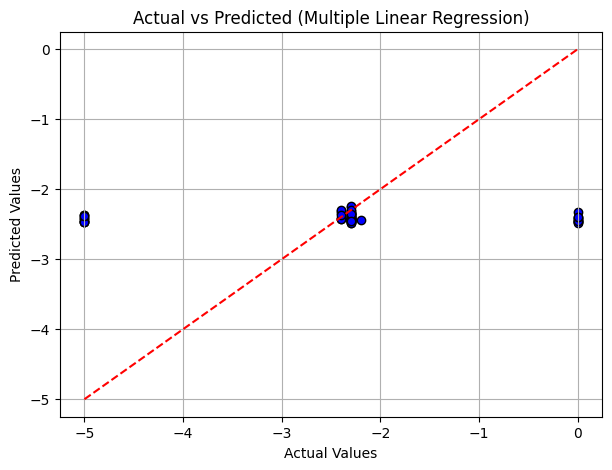

In [ ]:
#  Visualization of Actual vs Predicted

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='blue', edgecolors='black')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Multiple Linear Regression)")
plt.grid(True)
plt.show()

In [8]:
#  9. Optional: Feature Importance (Coefficient Magnitude)

coef_table = pd.DataFrame({
    'Feature': ['Intercept'] + list(data.columns[1:]),
    'Coefficient': beta
})

display(coef_table.sort_values('Coefficient', key=np.abs, ascending=False))

,Feature,Coefficient
1,Prismatic coefficient,-3.681150
2,Length-displacement ratio,-1.201404
4,Length-beam ratio,1.101712
5,Froude number,-0.720828
3,Beam-draught ratio,0.457902
0,Intercept,0.277258
6,Residuary resistance per unit weight of displa...,0.002765
